In [1]:
import tqdm

In [2]:
import os

from pyspark.sql import SparkSession
from pyspark.ml.feature import Word2Vec
from pyspark.sql import functions as F
from pyspark.sql.functions import col, when, regexp_extract
from pyspark.sql.types import NumericType, StringType, StructType, StructField, DoubleType, TimestampType
from itertools import combinations


import matplotlib.pyplot as plt
import math

Matplotlib created a temporary cache directory at /scratch/ysuh2/job_48477793/matplotlib-la_kh4qz because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [27]:
# for memeory of 128gb 8 cores
spark = (
    SparkSession.builder
    .appName("young-job")
    .config("spark.driver.memory", "2g")
    .config("spark.executor.instances", "7")
    .config("spark.executor.memory", "18g")
    .getOrCreate()
)

In [28]:
schema = StructType([
    StructField("network_code", StringType(), True),
    StructField("receiver_code", StringType(), True),
    StructField("receiver_type", StringType(), True),
    StructField("receiver_latitude", DoubleType(), True),
    StructField("receiver_longitude", DoubleType(), True),
    StructField("receiver_elevation_m", DoubleType(), True),

    StructField("p_arrival_sample", DoubleType(), True),
    StructField("p_status", StringType(), True),
    StructField("p_weight", DoubleType(), True),
    StructField("p_travel_sec", DoubleType(), True),

    StructField("s_arrival_sample", DoubleType(), True),
    StructField("s_status", StringType(), True),
    StructField("s_weight", DoubleType(), True),

    StructField("source_id", StringType(), True),
    StructField("source_origin_time", TimestampType(), True),
    StructField("source_origin_uncertainty_sec", DoubleType(), True),
    StructField("source_latitude", DoubleType(), True),
    StructField("source_longitude", DoubleType(), True),
    StructField("source_error_sec", DoubleType(), True),
    StructField("source_gap_deg", DoubleType(), True),
    StructField("source_horizontal_uncertainty_km", DoubleType(), True),
    StructField("source_depth_km", DoubleType(), True),
    StructField("source_depth_uncertainty_km", DoubleType(), True),
    StructField("source_magnitude", DoubleType(), True),
    StructField("source_magnitude_type", StringType(), True),
    StructField("source_magnitude_author", StringType(), True),
    StructField("source_mechanism_strike_dip_rake", StringType(), True),

    StructField("source_distance_deg", DoubleType(), True),
    StructField("source_distance_km", DoubleType(), True),
    StructField("back_azimuth_deg", DoubleType(), True),

    StructField("snr_db", StringType(), True),
    StructField("coda_end_sample", StringType(), True),

    StructField("trace_start_time", TimestampType(), True),
    StructField("trace_category", StringType(), True),
    StructField("trace_name", StringType(), True),
])

In [29]:
df = (
    spark.read
    .option("header", True)
    .schema(schema)
    .csv("data/merge.csv")
)


# formatting column `coda_end_sample (ex: [[####]] to #### doubles)
df = df.withColumn(
    "coda_end_sample",
    regexp_extract(col("coda_end_sample"), r"([0-9]*\.?[0-9]+)", 1).cast("double")
)

In [6]:
df.count()

1268314

In [7]:
import requests
import pandas as pd

# Get the active Spark Context and URL
sc = spark.sparkContext
url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"

# Fetch the executor data from the API
response = requests.get(url)
executors = response.json()

# Format into a readable DataFrame
exec_df = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
exec_df['maxMemory_GB'] = (exec_df['maxMemory'] / (1024**3)).round(2)
exec_df

,id,totalCores,maxMemory,activeTasks,isActive,maxMemory_GB
0,driver,8,1099746508,0,True,1.02


In [8]:
df.printSchema()

root
 |-- network_code: string (nullable = true)
 |-- receiver_code: string (nullable = true)
 |-- receiver_type: string (nullable = true)
 |-- receiver_latitude: double (nullable = true)
 |-- receiver_longitude: double (nullable = true)
 |-- receiver_elevation_m: double (nullable = true)
 |-- p_arrival_sample: double (nullable = true)
 |-- p_status: string (nullable = true)
 |-- p_weight: double (nullable = true)
 |-- p_travel_sec: double (nullable = true)
 |-- s_arrival_sample: double (nullable = true)
 |-- s_status: string (nullable = true)
 |-- s_weight: double (nullable = true)
 |-- source_id: string (nullable = true)
 |-- source_origin_time: timestamp (nullable = true)
 |-- source_origin_uncertainty_sec: double (nullable = true)
 |-- source_latitude: double (nullable = true)
 |-- source_longitude: double (nullable = true)
 |-- source_error_sec: double (nullable = true)
 |-- source_gap_deg: double (nullable = true)
 |-- source_horizontal_uncertainty_km: double (nullable = true)
 |

### 🔹 Receiver Information
- **network_code**: string  
- **receiver_code**: string  
- **receiver_type**: string  
- **receiver_latitude**: double  
- **receiver_longitude**: double  
- **receiver_elevation_m**: double  

### 🔹 P-Wave Data
- **p_arrival_sample**: double  
- **p_status**: string  
- **p_weight**: double  
- **p_travel_sec**: double  

### 🔹 S-Wave Data
- **s_arrival_sample**: double  
- **s_status**: string  
- **s_weight**: double  

### 🔹 Source Information
- **source_id**: string  
- **source_origin_time**: timestamp  
- **source_origin_uncertainty_sec**: double  
- **source_latitude**: double  
- **source_longitude**: double  
- **source_error_sec**: double  
- **source_gap_deg**: double  
- **source_horizontal_uncertainty_km**: double  
- **source_depth_km**: double  
- **source_depth_uncertainty_km**: double  
- **source_magnitude**: double  
- **source_magnitude_type**: string  
- **source_magnitude_author**: string  
- **source_mechanism_strike_dip_rake**: string  

### 🔹 Distance & Geometry
- **source_distance_deg**: double  
- **source_distance_km**: double  
- **back_azimuth_deg**: double  

### 🔹 Signal & Trace
- **snr_db**: string  
- **coda_end_sample**: double *(e.g., [[1234]])*  
- **trace_start_time**: timestamp  
- **trace_category**: string  
- **trace_name**: string  t_time
trace_category
trace_name

In [20]:
# number of observations and columns
df_shape = df.count(), len(df.columns)
print(df_shape)

(1268314, 35)


In [21]:
# null count per column using isNull() only
df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]).show(truncate=False, vertical=True)

-RECORD 0-----------------------------------
 network_code                     | 0       
 receiver_code                    | 0       
 receiver_type                    | 0       
 receiver_latitude                | 0       
 receiver_longitude               | 2657    
 receiver_elevation_m             | 2657    
 p_arrival_sample                 | 238083  
 p_status                         | 235426  
 p_weight                         | 238257  
 p_travel_sec                     | 238083  
 s_arrival_sample                 | 238083  
 s_status                         | 238083  
 s_weight                         | 238238  
 source_id                        | 238083  
 source_origin_time               | 238083  
 source_origin_uncertainty_sec    | 1128020 
 source_latitude                  | 238083  
 source_longitude                 | 238083  
 source_error_sec                 | 808811  
 source_gap_deg                   | 887497  
 source_horizontal_uncertainty_km | 827576  
 source_de

In [22]:
# null count per column using isNull() and isnan() but excluding timestamp columns
no_ts = df.drop('source_origin_time', 'trace_start_time')
no_ts.cache()
no_ts.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in no_ts.columns]).show(truncate=False, vertical=True)

-RECORD 0-----------------------------------
 network_code                     | 0       
 receiver_code                    | 0       
 receiver_type                    | 0       
 receiver_latitude                | 0       
 receiver_longitude               | 2657    
 receiver_elevation_m             | 2657    
 p_arrival_sample                 | 238083  
 p_status                         | 235426  
 p_weight                         | 238257  
 p_travel_sec                     | 238083  
 s_arrival_sample                 | 238083  
 s_status                         | 238083  
 s_weight                         | 238238  
 source_id                        | 238083  
 source_origin_uncertainty_sec    | 1128020 
 source_latitude                  | 238083  
 source_longitude                 | 238083  
 source_error_sec                 | 808811  
 source_gap_deg                   | 887497  
 source_horizontal_uncertainty_km | 827576  
 source_depth_km                  | 238132  
 source_de

In [23]:
# percentage of data missing per column
no_ts.select([F.mean(F.when(F.isnan(c) | F.col(c).isNull(), 1).otherwise(0)* 100).alias(f"{c}_percent_missing") for c in no_ts.columns]).show(truncate=False, vertical=True)

-RECORD 0---------------------------------------------------------------
 network_code_percent_missing                     | 0.0                 
 receiver_code_percent_missing                    | 0.0                 
 receiver_type_percent_missing                    | 0.0                 
 receiver_latitude_percent_missing                | 0.0                 
 receiver_longitude_percent_missing               | 0.20949070971384057 
 receiver_elevation_m_percent_missing             | 0.20949070971384057 
 p_arrival_sample_percent_missing                 | 18.77161333865273   
 p_status_percent_missing                         | 18.56212262893889   
 p_weight_percent_missing                         | 18.78533233883723   
 p_travel_sec_percent_missing                     | 18.77161333865273   
 s_arrival_sample_percent_missing                 | 18.77161333865273   
 s_status_percent_missing                         | 18.77161333865273   
 s_weight_percent_missing                         |

In [24]:
# percentage of data missing for timestamp columns
ts_cols = df.select('source_origin_time', 'trace_start_time')
ts_cols.select([F.mean(F.when(F.col(c).isNull(), 1).otherwise(0) * 100).alias(f"{c}_percent_missing") for c in ts_cols.columns]).show(truncate=False, vertical=True)

-RECORD 0-------------------------------------------------
 source_origin_time_percent_missing | 18.77161333865273   
 trace_start_time_percent_missing   | 0.41898141942768113 



In [25]:
df.summary().show(truncate=False)

# 4) Separate numeric and categorical columns
num_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, NumericType)]
cat_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType)]

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

+-------+----------------------------------------------+------------------+------------------+------------------+-------------------+--------------------+-----------------+---------+-------------------+------------------+------------------+---------+-------------------+--------------------+-----------------------------+------------------+-------------------+-------------------+------------------+--------------------------------+-----------------+---------------------------+------------------+---------------------+-----------------------+--------------------------------+-------------------+------------------+------------------+-------------------------------------+------------------+----------------+-------------------------+
|summary|network_code                                  |receiver_code     |receiver_type     |receiver_latitude |receiver_longitude |receiver_elevation_m|p_arrival_sample |p_status |p_weight           |p_travel_sec      |s_arrival_sample  |s_status |s_weight       

In [29]:
#numerica statistics
if num_cols:
    df.select(num_cols).summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max").show(truncate=False, vertical=True)

# checking duplicates
total_rows = df.count()
distinct_rows = df.dropDuplicates().count()
print("Duplicate rows:", total_rows - distinct_rows)

# top categorical values
for c in cat_cols[:10]:   # limit to first 10 categorical columns
    print(f"\nTop values for: {c}")
    (
        df.groupBy(c)
          .count()
          .orderBy(F.desc("count"))
          .show(10, truncate=False)
    )

-RECORD 0-----------------------------------------------
 summary                          | count               
 receiver_latitude                | 1268314             
 receiver_longitude               | 1265657             
 receiver_elevation_m             | 1265657             
 p_arrival_sample                 | 1030231             
 p_weight                         | 1030057             
 p_travel_sec                     | 1030231             
 s_arrival_sample                 | 1030231             
 s_weight                         | 1030076             
 source_origin_uncertainty_sec    | 140294              
 source_latitude                  | 1030231             
 source_longitude                 | 1030231             
 source_error_sec                 | 459503              
 source_gap_deg                   | 380817              
 source_horizontal_uncertainty_km | 440738              
 source_depth_km                  | 1030182             
 source_depth_uncertainty_km   

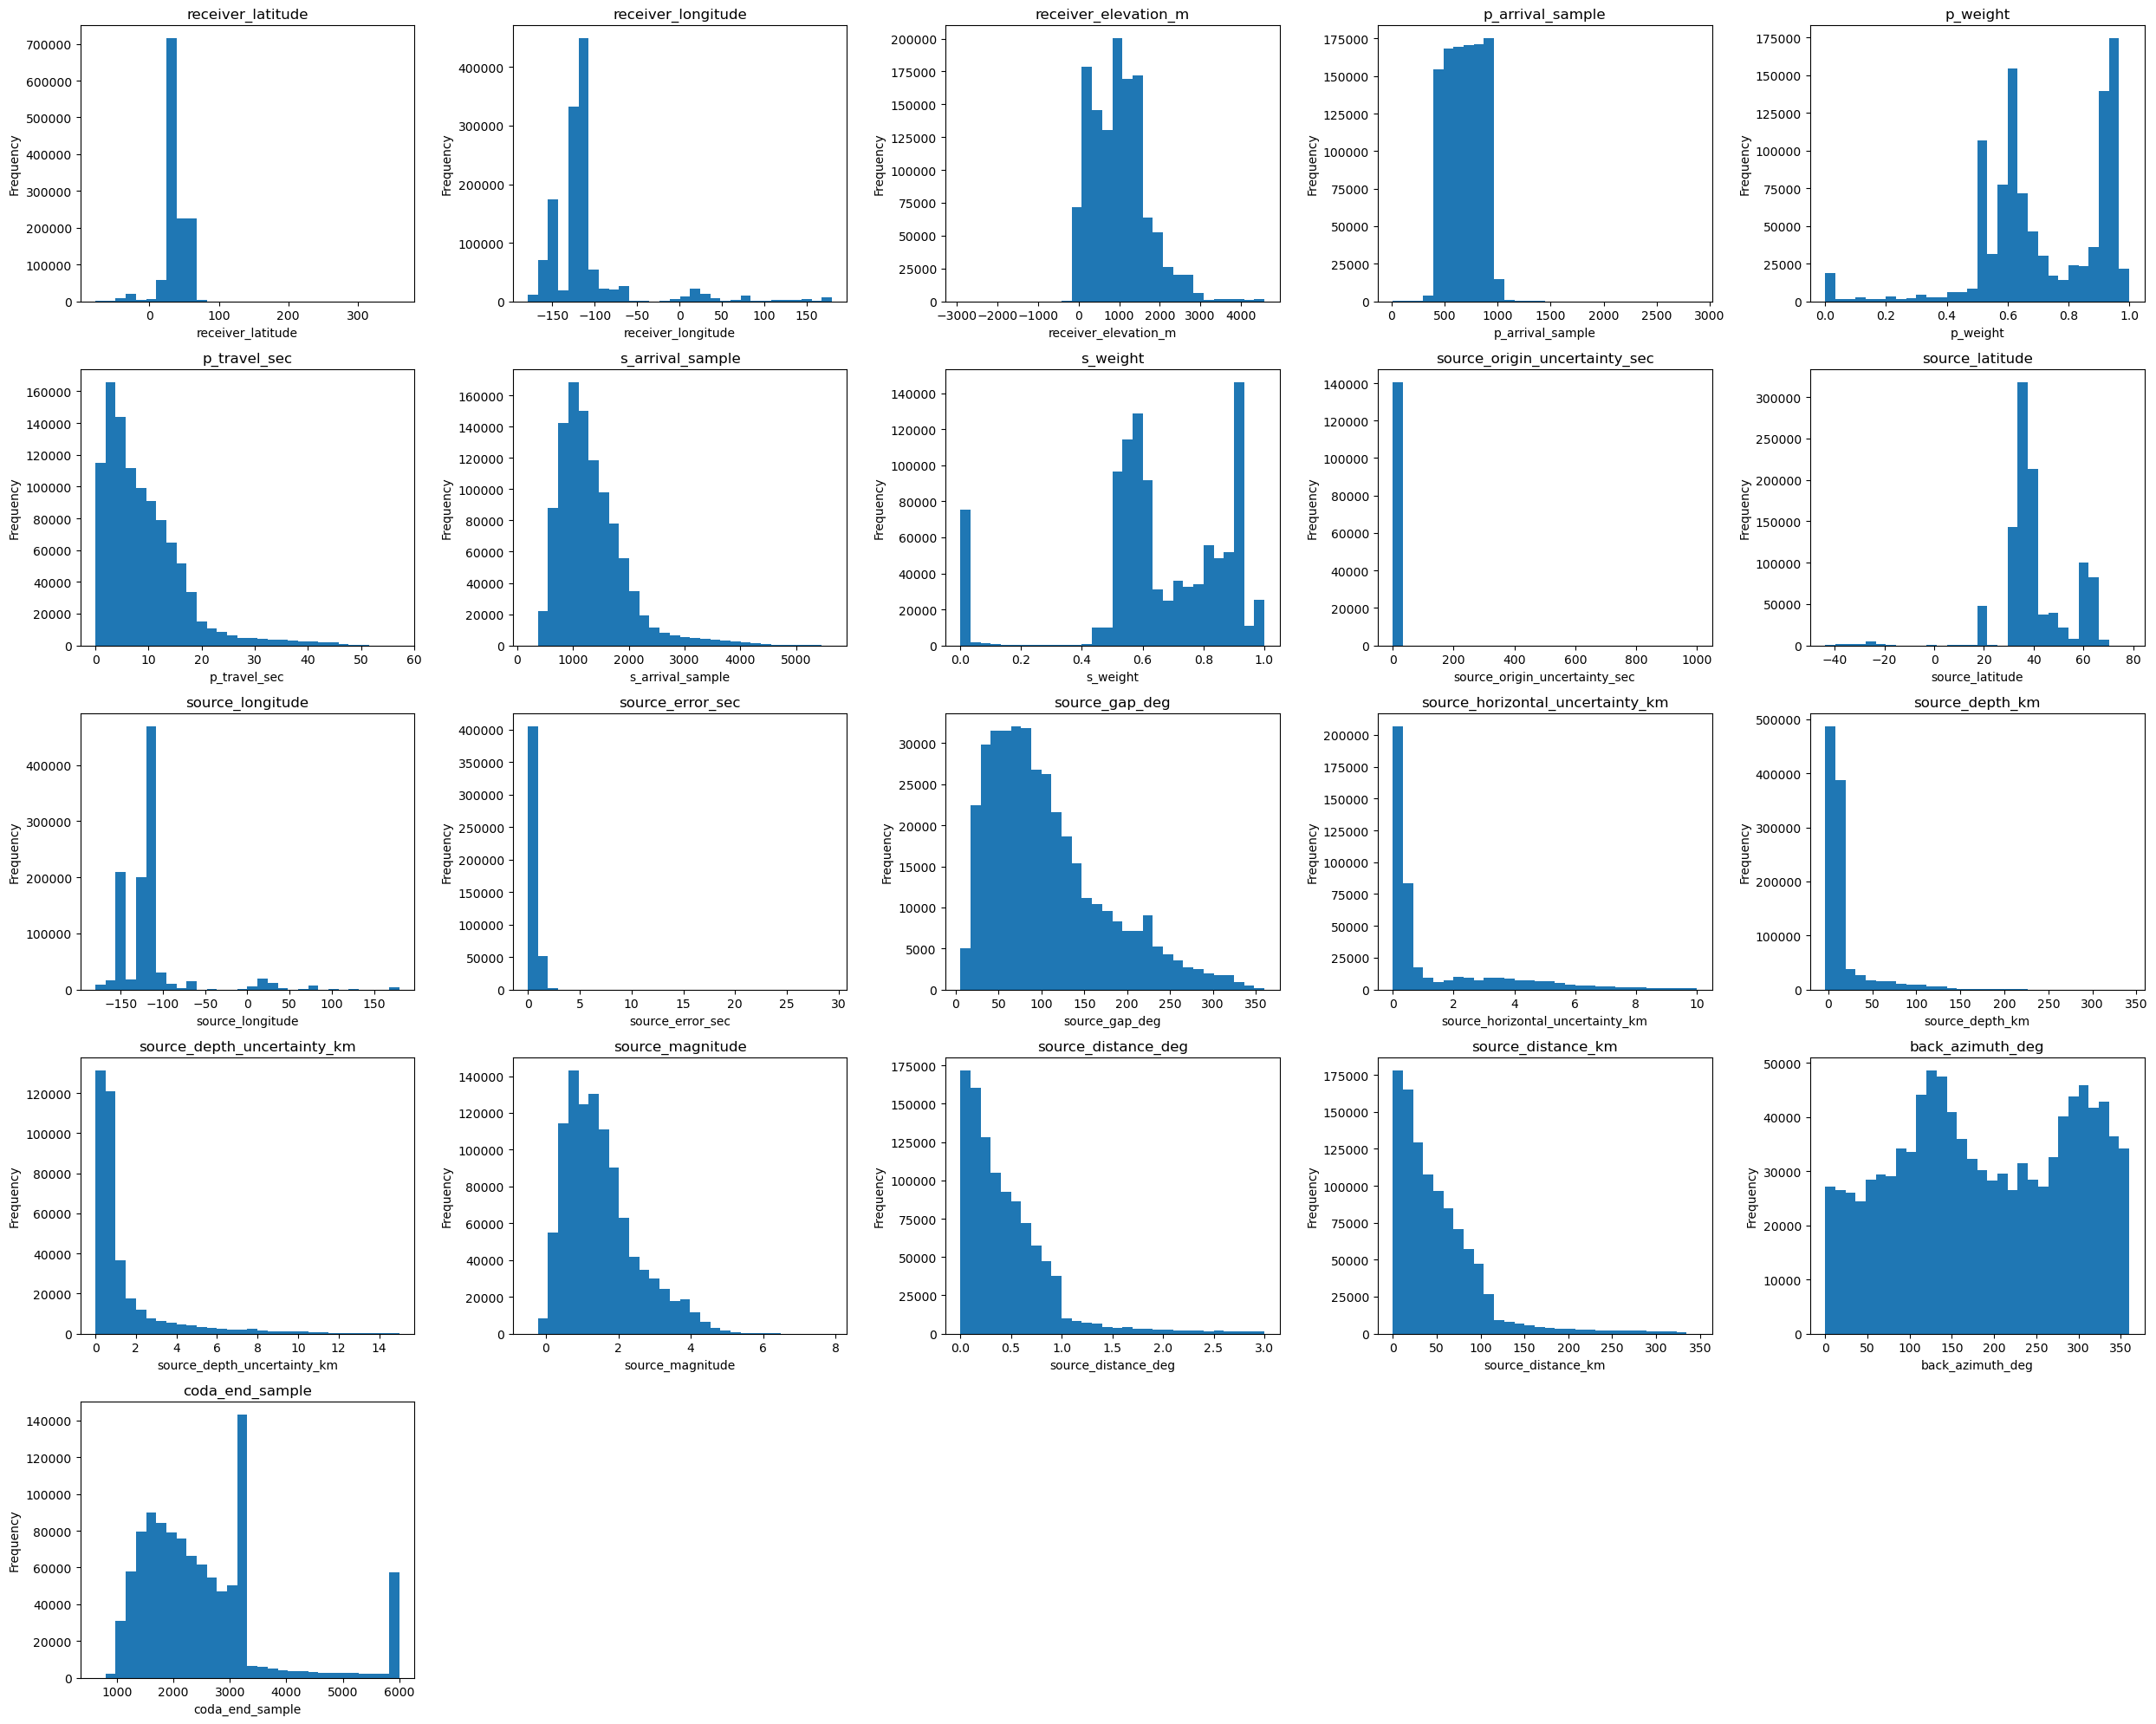

In [27]:
n_cols = 5  # number of plots per row
n_plots = len(num_cols)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  # make indexing easier

for i, col_name in enumerate(num_cols):
    pdf = df.select(col_name).dropna().toPandas()
    
    axes[i].hist(pdf[col_name], bins=30)
    axes[i].set_title(f"{col_name}")
    axes[i].set_xlabel(col_name)
    axes[i].set_ylabel("Frequency")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

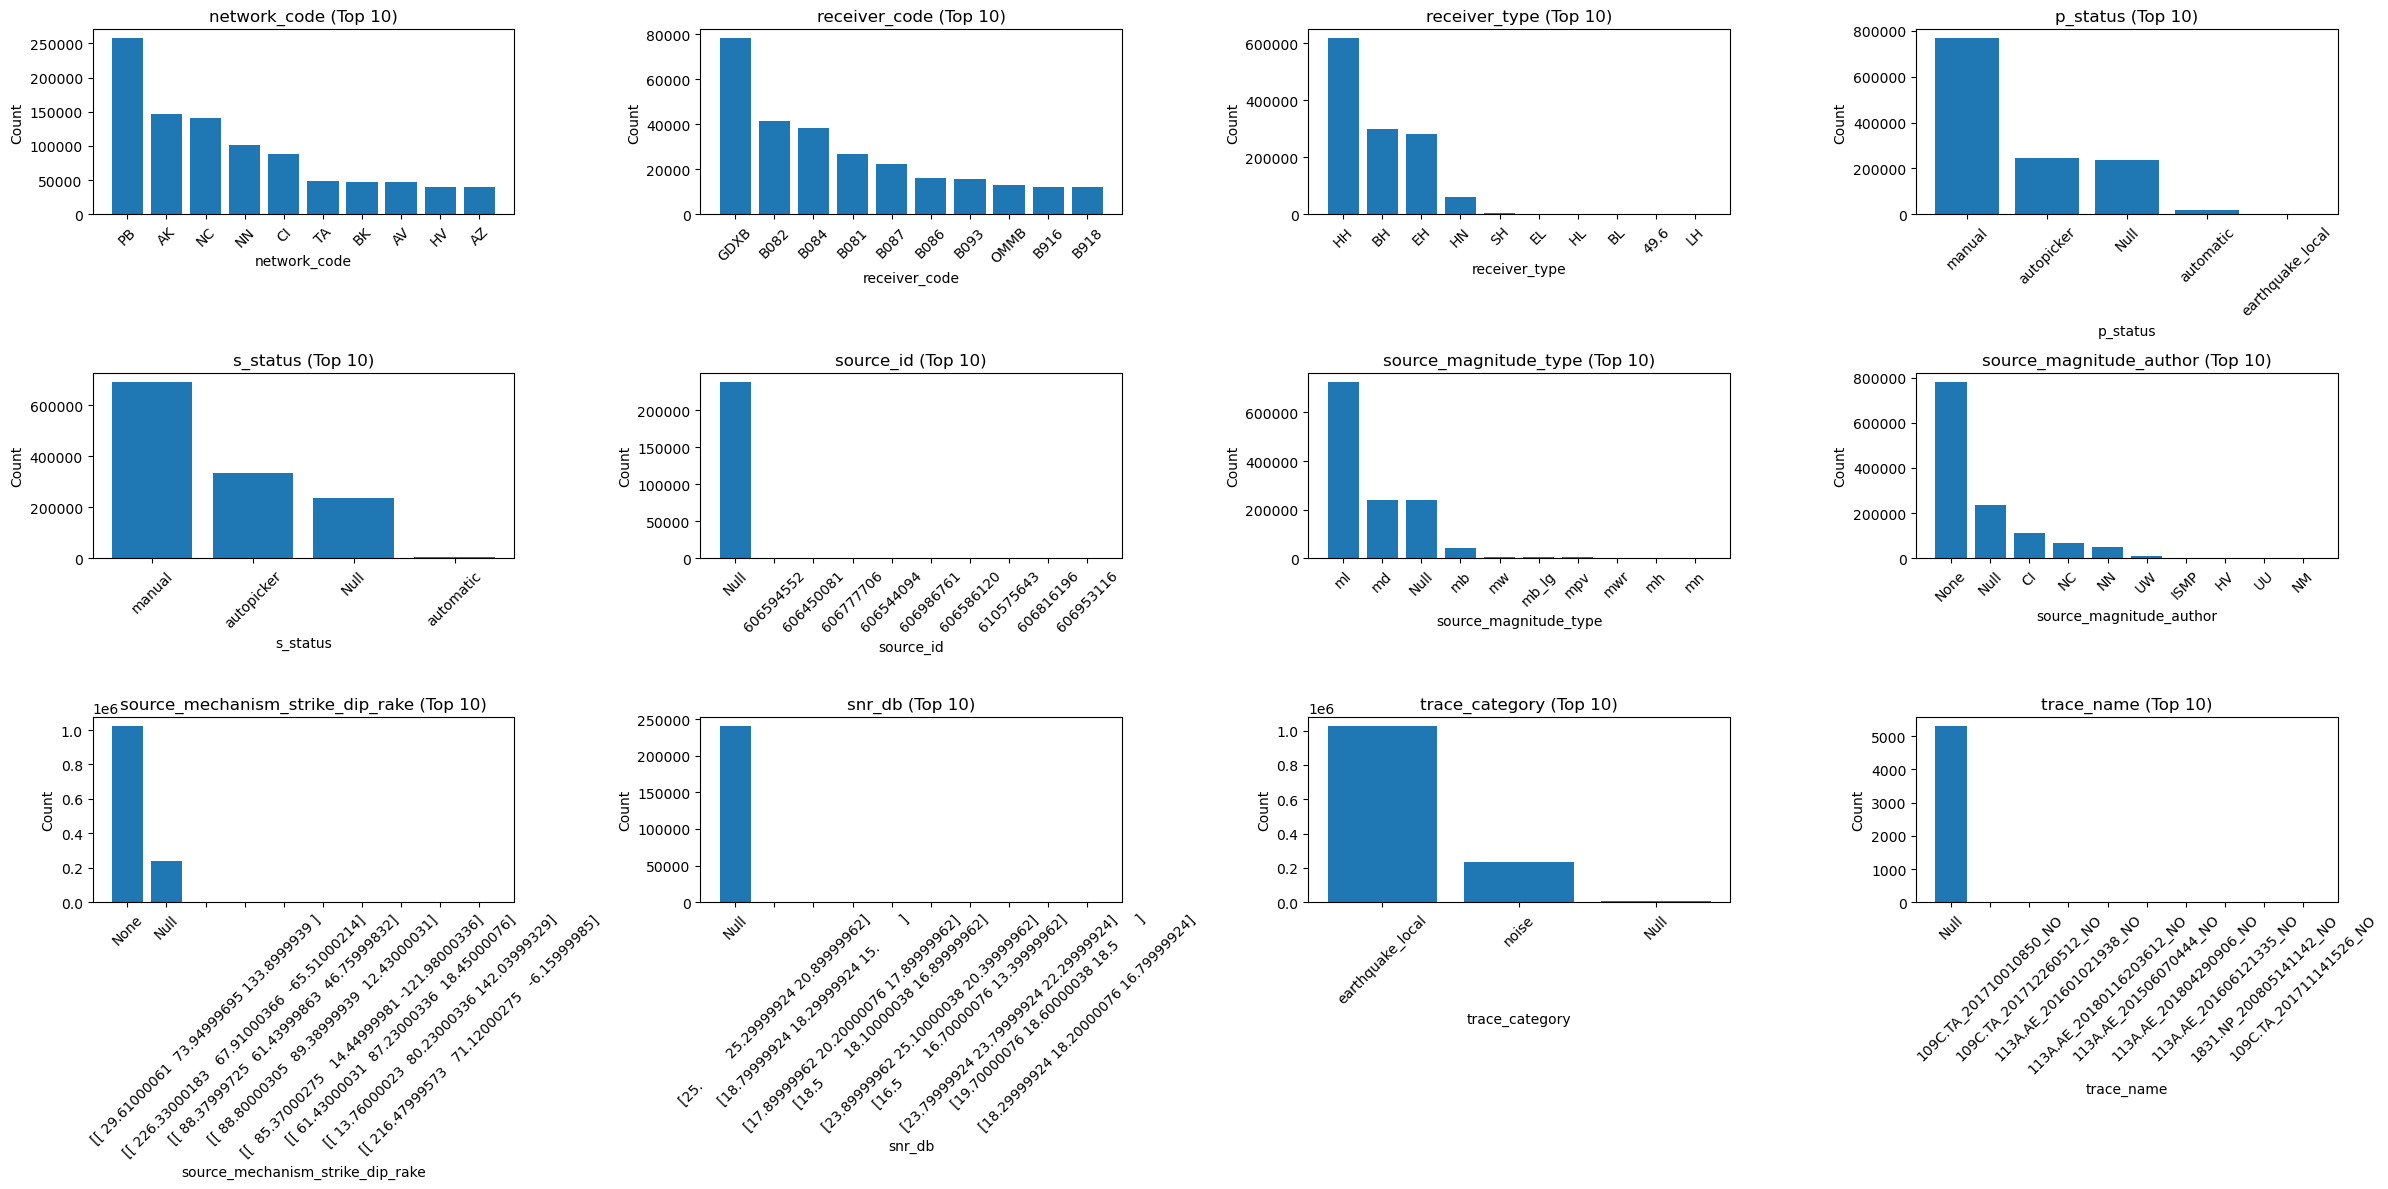

In [28]:
top_n = 10
n_cols = 4
n_plots = len(cat_cols)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col_name in enumerate(cat_cols):
    agg_df = (
        df.withColumn(
            col_name,
            when(col(col_name).isNull(),"Null").otherwise(col(col_name)) 
        )
        .groupBy(col_name)
        .count()
        .orderBy("count", ascending=False)
        .limit(top_n)
    )
    
    pdf = agg_df.toPandas()
    
    axes[i].bar(pdf[col_name], pdf["count"])
    axes[i].set_title(f"{col_name} (Top {top_n})")
    axes[i].set_xlabel(col_name)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [12]:
# checking for duplicate values in trace names
from pyspark.sql.functions import countDistinct, dis
unique_counts = df.select(countDistinct("trace_name")).collect()
unique_counts
# nuniuqe trace names - null trace names
#1268314 - 5314 == 1263000

[Row(count(DISTINCT trace_name)=1263000)]

1263000

In [30]:
df.groupBy("trace_category").count().orderBy(col("count").desc()).show()

+----------------+-------+
|  trace_category|  count|
+----------------+-------+
|earthquake_local|1027574|
|           noise| 235426|
|            NULL|   5314|
+----------------+-------+



In [10]:
numeric_cols

['receiver_latitude',
 'receiver_longitude',
 'receiver_elevation_m',
 'p_arrival_sample',
 'p_weight',
 'p_travel_sec',
 's_arrival_sample',
 's_weight',
 'source_origin_uncertainty_sec',
 'source_latitude',
 'source_longitude',
 'source_error_sec',
 'source_gap_deg',
 'source_horizontal_uncertainty_km',
 'source_depth_km',
 'source_depth_uncertainty_km',
 'source_magnitude',
 'source_distance_deg',
 'source_distance_km',
 'back_azimuth_deg',
 'coda_end_sample']

In [12]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

# Select numeric columns and assemble into a single vector column
df_clean = df.dropna(subset=numeric_cols)
numeric_cols = [f.name for f in df_clean.schema.fields if isinstance(f.dataType, NumericType)]


assembler = VectorAssembler(inputCols=numeric_cols, outputCol="features")
df_vector = assembler.transform(df_clean).select("features")

# Calculate the Pearson correlation matrix
# Note: Result is a DataFrame with a single row containing a DenseMatrix
matrix = Correlation.corr(df_vector, "features", method="pearson").head()
result_matrix = matrix[0].toArray()

print(result_matrix)

[[ 1.         -0.37845413  0.00135388 -0.0131546  -0.0834282   0.41242765
   0.40028096  0.1775259   0.21558431  0.99800109 -0.42379155  0.22012513
   0.09544831  0.43987021  0.55420792 -0.06315292  0.21356629  0.39293545
   0.39251369 -0.07974554  0.282975  ]
 [-0.37845413  1.         -0.18336995 -0.06752897  0.02006504 -0.16500334
  -0.16666004 -0.01702294 -0.21615744 -0.37587938  0.88042212  0.11848116
  -0.13609206 -0.17902902 -0.25417973  0.10028049  0.12412218 -0.16039788
  -0.15998949  0.04419576 -0.01111401]
 [ 0.00135388 -0.18336995  1.          0.01367635 -0.0023521  -0.00447776
  -0.00845355  0.03537802  0.00253286 -0.00270352 -0.17068286  0.02050315
  -0.05330288 -0.07599956  0.02408577 -0.23264705 -0.06551951 -0.0147847
  -0.01483249 -0.02655309 -0.17906099]
 [-0.0131546  -0.06752897  0.01367635  1.         -0.07138509 -0.01175589
   0.22417986 -0.01801012  0.05960099 -0.0144548  -0.06711051 -0.05732258
   0.04590759  0.0033305  -0.01586821 -0.01212769 -0.01300682 -0.01567

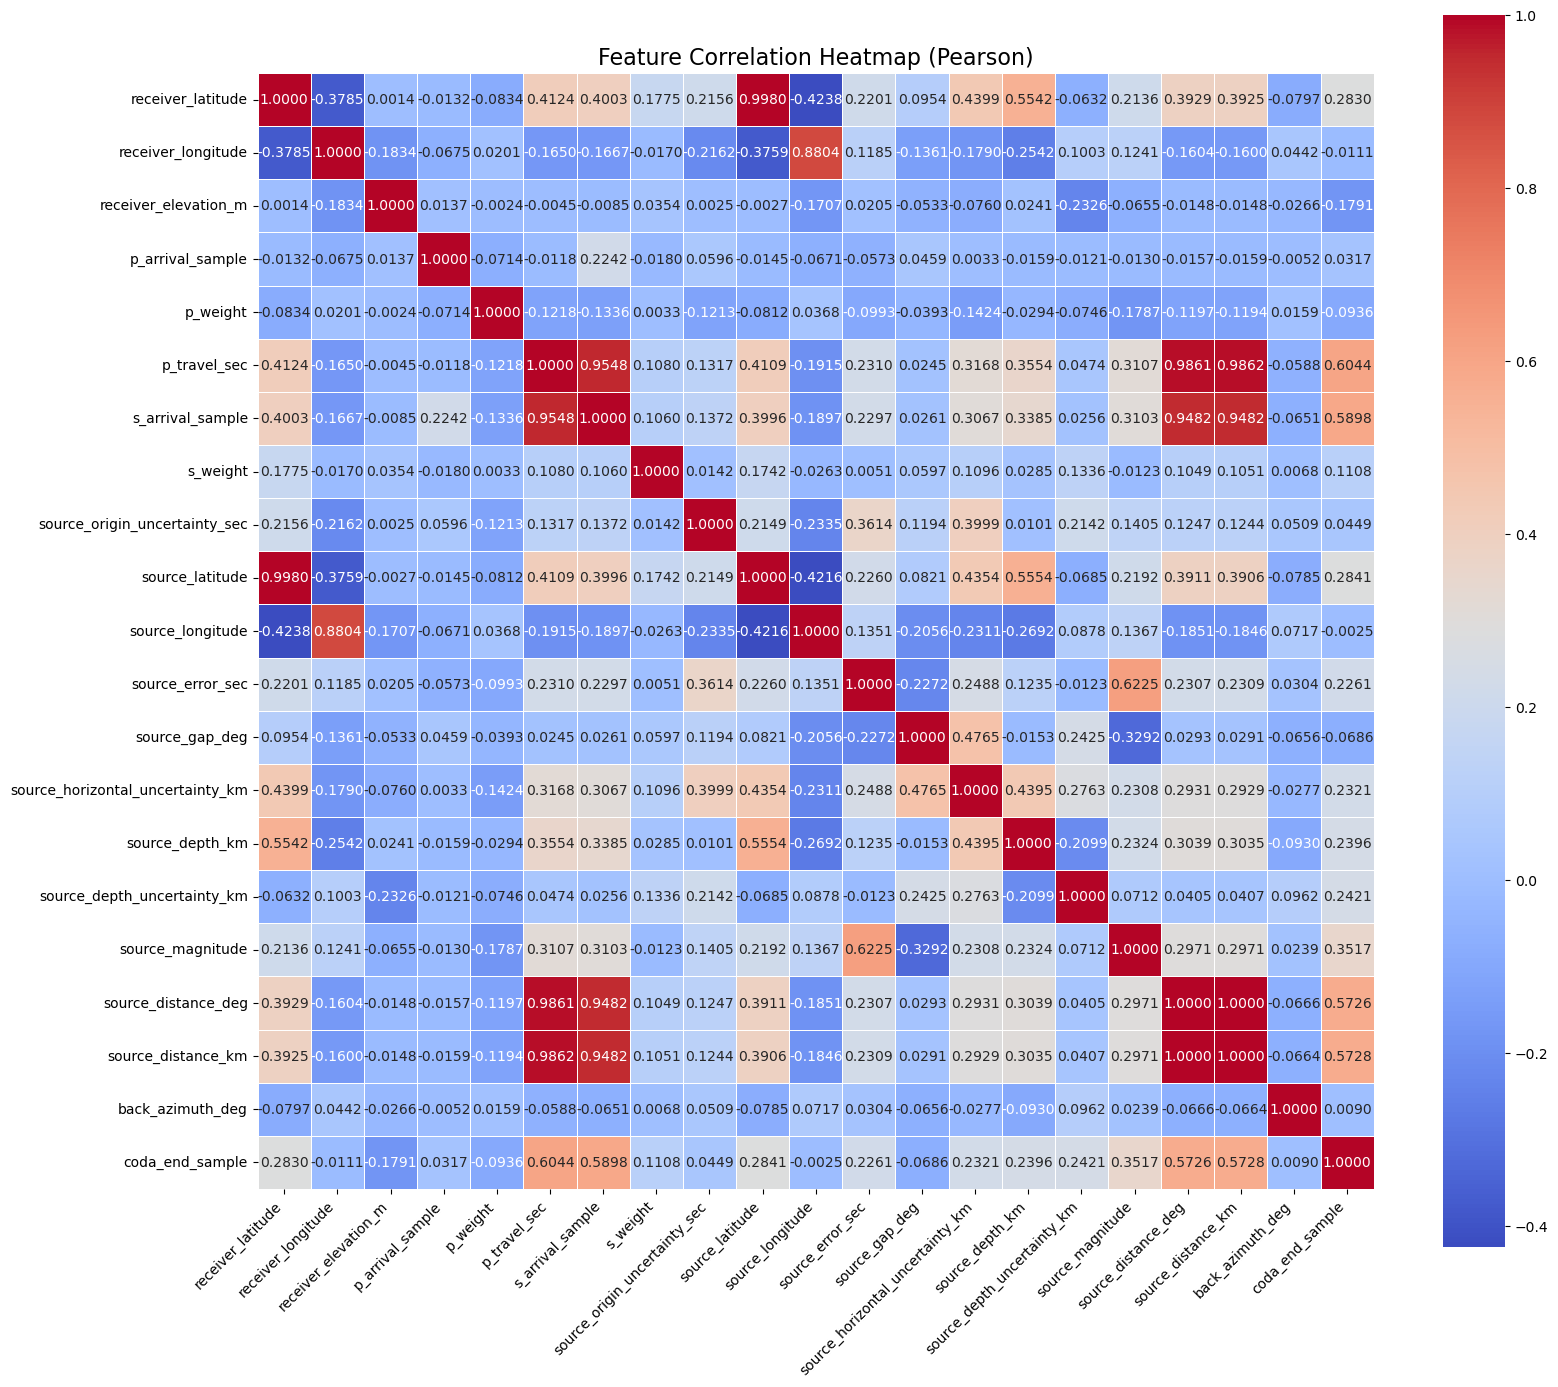

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Convert the numpy array (result_matrix) into a Pandas DataFrame
# We use numeric_cols for labels so we know which feature is which
corr_df = pd.DataFrame(result_matrix, index=numeric_cols, columns=numeric_cols)

# 2. Create the plot
plt.figure(figsize=(18, 16)) # Increase size if you have many columns

# 3. Draw the heatmap
sns.heatmap(
    corr_df, 
    annot=True,          # Show the numeric values in the cells
    fmt=".4f",           # Round to 4 decimal places
    cmap='coolwarm',     # Red for positive, Blue for negative correlation
    linewidths=0.5,      # Add small lines between cells
    square=True          # Ensure the cells are perfect squares
)

plt.title('Feature Correlation Heatmap (Pearson)', fontsize=16)
plt.xticks(rotation=45, ha='right') # Tilt the labels for better fit
plt.yticks(rotation=0)

plt.show()

In [18]:
df.select("source_latitude","receiver_latitude").where(F.col("source_latitude").isNotNull() & F.col("receiver_latitude").isNotNull()).show()

+---------------+-----------------+
|source_latitude|receiver_latitude|
+---------------+-----------------+
|        33.7496|          32.8889|
|        32.7077|          32.8889|
|        32.7253|          32.8889|
|        32.7063|          32.8889|
|        31.9679|          32.8889|
|        32.8312|          32.8889|
|        32.8297|          32.8889|
|        32.8261|          32.8889|
|        32.8327|          32.8889|
|        32.7154|          32.8889|
|        32.9898|          32.8889|
|        33.2446|          32.8889|
|        32.6571|          32.8889|
|        33.2297|          32.8889|
|         32.067|          32.8889|
|        32.7322|          32.8889|
|        32.7098|          32.8889|
|        32.6944|          32.8889|
|        33.4264|          32.8889|
|         32.732|          32.8889|
+---------------+-----------------+
only showing top 20 rows



# list of preprocessing we can do
- minmax scaling on waveform data
- PCA on numerical columns to narrow out "important features"
- metadata missing values imputing
- 

/scratch/ysuh2/job_48477793/ipykernel_884924/974713234.py:10: DtypeWarning: Columns (7,11,13,14,24,25,26,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)


total events in csv file: 1265657
total events selected: 2278


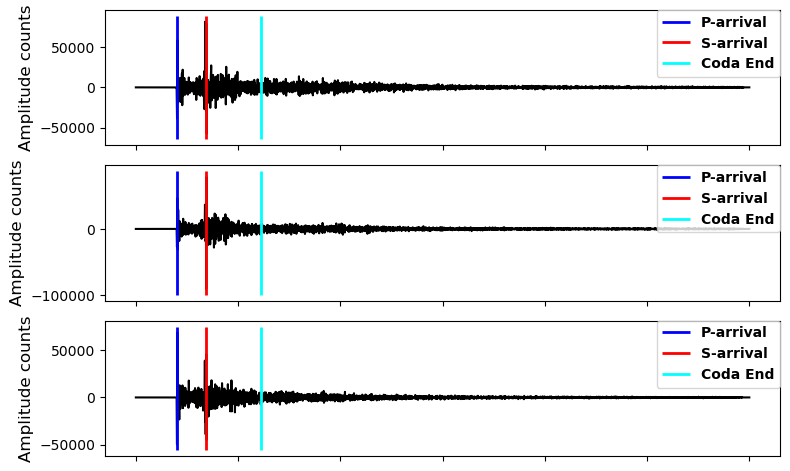

back_azimuth_deg 56.9
coda_end_sample [[1228.]]
network_code CN
p_arrival_sample 400.0
p_status manual
p_travel_sec 4.630000114440918
p_weight 0.5
receiver_code A16
receiver_elevation_m 13.0
receiver_latitude 47.468
receiver_longitude -70.0096
receiver_type HH
s_arrival_sample 686.0
s_status manual
s_weight 0.5
snr_db [72.40000153 61.70000076 62.20000076]
source_depth_km 17.42
source_depth_uncertainty_km 7.6
source_distance_deg 0.18
source_distance_km 19.21
source_error_sec 0.8797
source_gap_deg 37.699
source_horizontal_uncertainty_km 2.68655
source_id 606589340
source_latitude 47.3748
source_longitude -70.2239
source_magnitude 3.7
source_magnitude_author None
source_magnitude_type mb_lg
source_mechanism_strike_dip_rake None
source_origin_time 2015-01-21 05:31:58.92
source_origin_uncertainty_sec 0.76
trace_category earthquake_local
trace_name A16.CN_20150121053158_EV
trace_start_time 2015-01-21 05:31:59.550000


Press a key to plot the next waveform! 


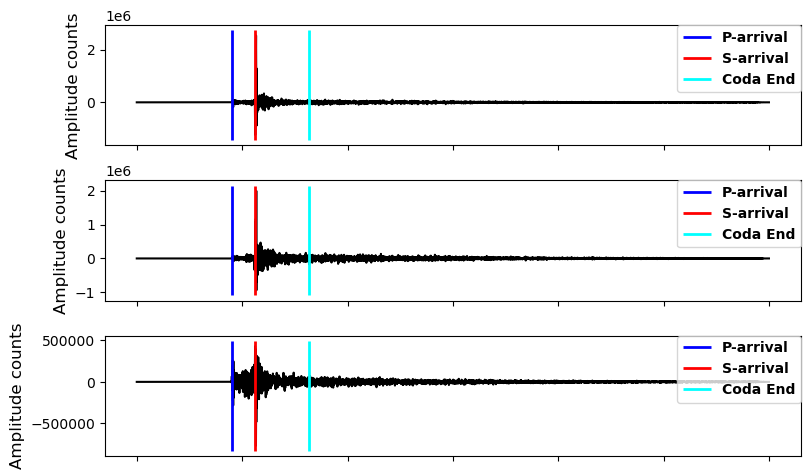

back_azimuth_deg 93.0
coda_end_sample [[1631.]]
network_code CN
p_arrival_sample 900.0
p_status manual
p_travel_sec 4.050000190734863
p_weight 0.5
receiver_code A64
receiver_elevation_m 132.0
receiver_latitude 47.8274
receiver_longitude -69.8914
receiver_type HH
s_arrival_sample 1120.0
s_status manual
s_weight 0.5
snr_db [70.69999695 74.40000153 66.80000305]
source_depth_km 14.69
source_depth_uncertainty_km None
source_distance_deg 0.16
source_distance_km 17.69
source_error_sec 1.3351
source_gap_deg 64.972
source_horizontal_uncertainty_km 4.95069
source_id 603236867
source_latitude 47.8351
source_longitude -70.1274
source_magnitude 4.4
source_magnitude_author None
source_magnitude_type mb
source_mechanism_strike_dip_rake None
source_origin_time 2013-07-11 20:16:07.07
source_origin_uncertainty_sec 0.59
trace_category earthquake_local
trace_name A64.CN_20130711201601_EV
trace_start_time 2013-07-11 20:16:02.120000


Press a key to plot the next waveform! 


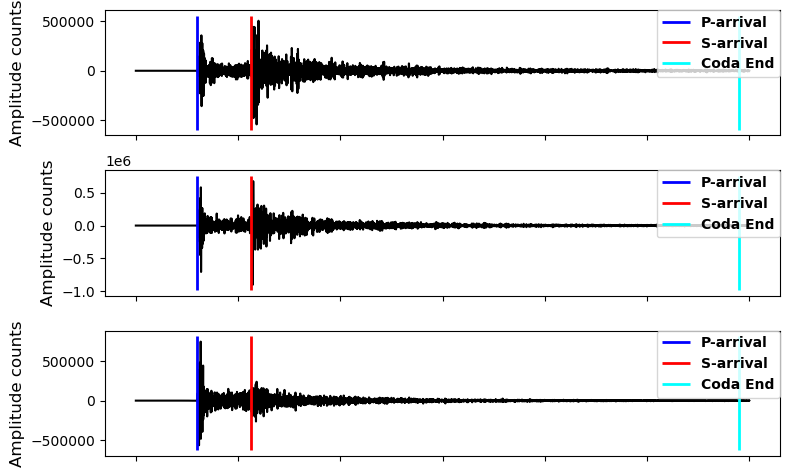

back_azimuth_deg 161.6
coda_end_sample [[5900.]]
network_code C1
p_arrival_sample 600.0
p_status manual
p_travel_sec 8.550000190734863
p_weight 0.5
receiver_code AC04
receiver_elevation_m 249.0
receiver_latitude -28.2046
receiver_longitude -71.0739
receiver_type HH
s_arrival_sample 1129.0
s_status manual
s_weight 0.5
snr_db [71.30000305 73.30000305 68.        ]
source_depth_km 44.67
source_depth_uncertainty_km None
source_distance_deg 0.05
source_distance_km 5.61
source_error_sec 1.7074
source_gap_deg 154.606
source_horizontal_uncertainty_km 8.87429
source_id 606918008
source_latitude -28.1566
source_longitude -71.0919
source_magnitude 4.2
source_magnitude_author None
source_magnitude_type mb
source_mechanism_strike_dip_rake None
source_origin_time 2014-06-16 23:19:54.05
source_origin_uncertainty_sec 0.78
trace_category earthquake_local
trace_name AC04.C1_20140616231955_EV
trace_start_time 2014-06-16 23:19:56.600000


KeyboardInterrupt: Interrupted by user

In [23]:
import pandas as pd
import h5py
import numpy as np
import matplotlib.pyplot as plt

file_name = "data/merge.hdf5"
csv_file = "data/merge.csv"

# reading the csv file into a dataframe:
df = pd.read_csv(csv_file)
print(f'total events in csv file: {len(df)}')
# filterering the dataframe
df = df[(df.trace_category == 'earthquake_local') & (df.source_distance_km <= 20) & (df.source_magnitude > 3)]
print(f'total events selected: {len(df)}')

# making a list of trace names for the selected data
ev_list = df['trace_name'].to_list()

# retrieving selected waveforms from the hdf5 file: 
dtfl = h5py.File(file_name, 'r')
for c, evi in enumerate(ev_list):
    dataset = dtfl.get('data/'+str(evi)) 
    # waveforms, 3 channels: first row: E channel, second row: N channel, third row: Z channel 
    data = np.array(dataset)

    fig = plt.figure()
    ax = fig.add_subplot(311)         
    plt.plot(data[:,0], 'k')
    plt.rcParams["figure.figsize"] = (8, 5)
    legend_properties = {'weight':'bold'}    
    plt.tight_layout()
    ymin, ymax = ax.get_ylim()
    pl = plt.vlines(dataset.attrs['p_arrival_sample'], ymin, ymax, color='b', linewidth=2, label='P-arrival')
    sl = plt.vlines(dataset.attrs['s_arrival_sample'], ymin, ymax, color='r', linewidth=2, label='S-arrival')
    cl = plt.vlines(dataset.attrs['coda_end_sample'], ymin, ymax, color='aqua', linewidth=2, label='Coda End')
    plt.legend(handles=[pl, sl, cl], loc = 'upper right', borderaxespad=0., prop=legend_properties)        
    plt.ylabel('Amplitude counts', fontsize=12) 
    ax.set_xticklabels([])

    ax = fig.add_subplot(312)         
    plt.plot(data[:,1], 'k')
    plt.rcParams["figure.figsize"] = (8, 5)
    legend_properties = {'weight':'bold'}    
    plt.tight_layout()
    ymin, ymax = ax.get_ylim()
    pl = plt.vlines(dataset.attrs['p_arrival_sample'], ymin, ymax, color='b', linewidth=2, label='P-arrival')
    sl = plt.vlines(dataset.attrs['s_arrival_sample'], ymin, ymax, color='r', linewidth=2, label='S-arrival')
    cl = plt.vlines(dataset.attrs['coda_end_sample'], ymin, ymax, color='aqua', linewidth=2, label='Coda End')
    plt.legend(handles=[pl, sl, cl], loc = 'upper right', borderaxespad=0., prop=legend_properties)        
    plt.ylabel('Amplitude counts', fontsize=12) 
    ax.set_xticklabels([])

    ax = fig.add_subplot(313)         
    plt.plot(data[:,2], 'k')
    plt.rcParams["figure.figsize"] = (8,5)
    legend_properties = {'weight':'bold'}    
    plt.tight_layout()
    ymin, ymax = ax.get_ylim()
    pl = plt.vlines(dataset.attrs['p_arrival_sample'], ymin, ymax, color='b', linewidth=2, label='P-arrival')
    sl = plt.vlines(dataset.attrs['s_arrival_sample'], ymin, ymax, color='r', linewidth=2, label='S-arrival')
    cl = plt.vlines(dataset.attrs['coda_end_sample'], ymin, ymax, color='aqua', linewidth=2, label='Coda End')
    plt.legend(handles=[pl, sl, cl], loc = 'upper right', borderaxespad=0., prop=legend_properties)        
    plt.ylabel('Amplitude counts', fontsize=12) 
    ax.set_xticklabels([])
    plt.show() 

    for at in dataset.attrs:
        print(at, dataset.attrs[at])    

    inp = input("Press a key to plot the next waveform!")
    if inp == "r":
        continue             

/scratch/ysuh2/job_48477793/ipykernel_884924/3439834415.py:2: DtypeWarning: Columns (7,11,13,14,24,25,26,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)


total events in csv file: 1265657
total events selected: 468


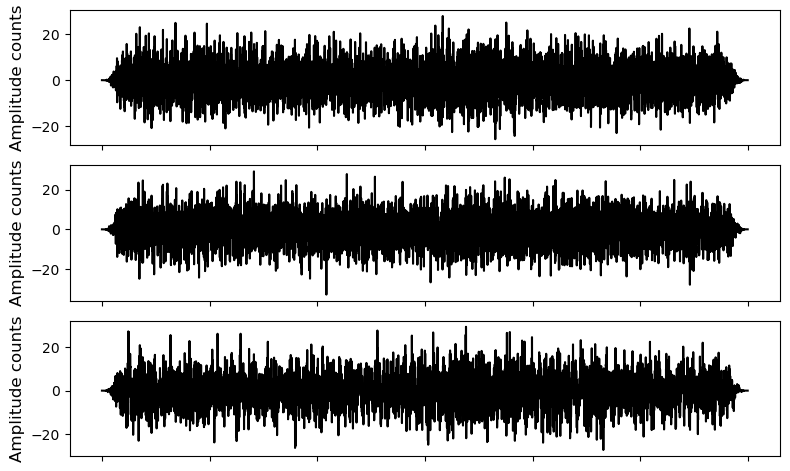

back_azimuth_deg 
coda_end_sample 
network_code NC
p_arrival_sample 
p_status 
p_travel_sec 
p_weight 
receiver_code PHOB
receiver_elevation_m 796.0
receiver_latitude 35.86661
receiver_longitude -120.4796
receiver_type HN
s_arrival_sample 
s_status 
s_weight 
snr_db 
source_depth_km 
source_depth_uncertainty_km 
source_distance_deg 
source_distance_km 
source_error_sec 
source_gap_deg 
source_horizontal_uncertainty_km 
source_id 
source_latitude 
source_longitude 
source_magnitude 
source_magnitude_author 
source_magnitude_type 
source_mechanism_strike_dip_rake 
source_origin_time 
source_origin_uncertainty_sec 
trace_category noise
trace_name PHOB.NC_200404261604_NO
trace_start_time 2004-04-26 16:04:00


Press a key to plot the next waveform! 


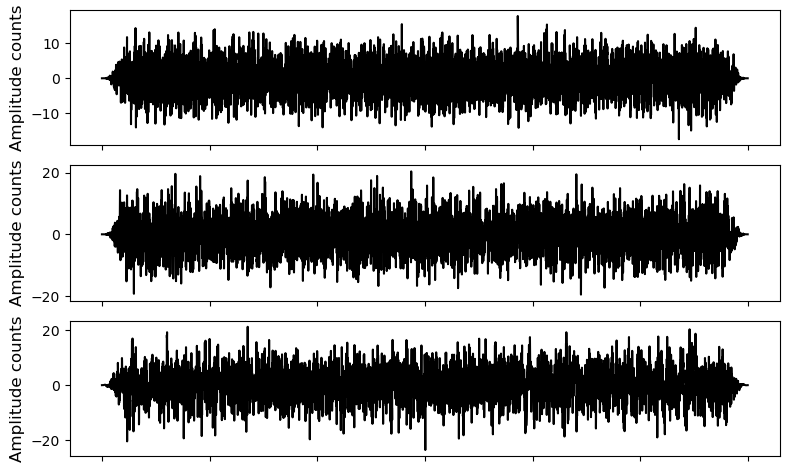

back_azimuth_deg 
coda_end_sample 
network_code NC
p_arrival_sample 
p_status 
p_travel_sec 
p_weight 
receiver_code PHOB
receiver_elevation_m 796.0
receiver_latitude 35.86661
receiver_longitude -120.4796
receiver_type HN
s_arrival_sample 
s_status 
s_weight 
snr_db 
source_depth_km 
source_depth_uncertainty_km 
source_distance_deg 
source_distance_km 
source_error_sec 
source_gap_deg 
source_horizontal_uncertainty_km 
source_id 
source_latitude 
source_longitude 
source_magnitude 
source_magnitude_author 
source_magnitude_type 
source_mechanism_strike_dip_rake 
source_origin_time 
source_origin_uncertainty_sec 
trace_category noise
trace_name PHOB.NC_200405020937_NO
trace_start_time 2004-05-02 09:37:00


Press a key to plot the next waveform! 


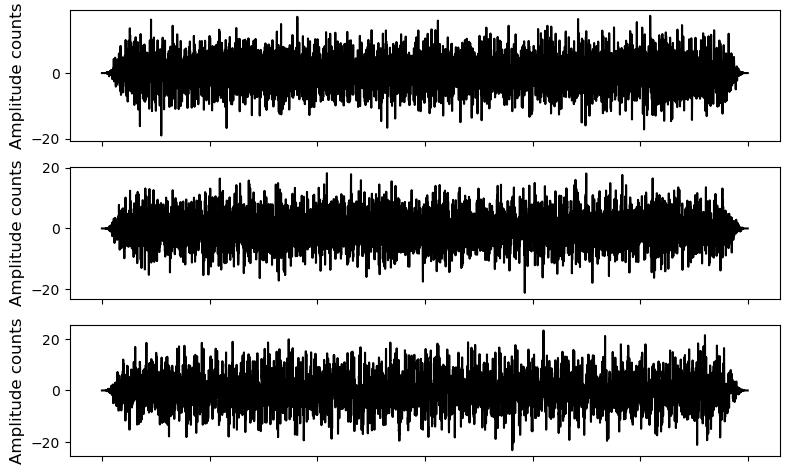

back_azimuth_deg 
coda_end_sample 
network_code NC
p_arrival_sample 
p_status 
p_travel_sec 
p_weight 
receiver_code PHOB
receiver_elevation_m 796.0
receiver_latitude 35.86661
receiver_longitude -120.4796
receiver_type HN
s_arrival_sample 
s_status 
s_weight 
snr_db 
source_depth_km 
source_depth_uncertainty_km 
source_distance_deg 
source_distance_km 
source_error_sec 
source_gap_deg 
source_horizontal_uncertainty_km 
source_id 
source_latitude 
source_longitude 
source_magnitude 
source_magnitude_author 
source_magnitude_type 
source_mechanism_strike_dip_rake 
source_origin_time 
source_origin_uncertainty_sec 
trace_category noise
trace_name PHOB.NC_200405030650_NO
trace_start_time 2004-05-03 06:50:00


KeyboardInterrupt: Interrupted by user

In [24]:
# reading the csv file into a dataframe:
df = pd.read_csv(csv_file)
print(f'total events in csv file: {len(df)}')
# filterering the dataframe
df = df[(df.trace_category == 'noise') & (df.receiver_code == 'PHOB') ]
print(f'total events selected: {len(df)}')

# making a list of trace names for the selected data
ev_list = df['trace_name'].to_list()[:200]

# retrieving selected waveforms from the hdf5 file: 
dtfl = h5py.File(file_name, 'r')
for c, evi in enumerate(ev_list):
    dataset = dtfl.get('data/'+str(evi)) 
    # waveforms, 3 channels: first row: E channel, second row: N channel, third row: Z channel 
    data = np.array(dataset)

    fig = plt.figure()
    ax = fig.add_subplot(311)         
    plt.plot(data[:,0], 'k')
    plt.rcParams["figure.figsize"] = (8, 5)
    legend_properties = {'weight':'bold'}    
    plt.tight_layout()
    plt.ylabel('Amplitude counts', fontsize=12) 
    ax.set_xticklabels([])

    ax = fig.add_subplot(312)         
    plt.plot(data[:,1], 'k')
    plt.rcParams["figure.figsize"] = (8, 5)
    legend_properties = {'weight':'bold'}    
    plt.tight_layout()     
    plt.ylabel('Amplitude counts', fontsize=12) 
    ax.set_xticklabels([])

    ax = fig.add_subplot(313)         
    plt.plot(data[:,2], 'k')
    plt.rcParams["figure.figsize"] = (8,5)
    legend_properties = {'weight':'bold'}    
    plt.tight_layout()     
    plt.ylabel('Amplitude counts', fontsize=12) 
    ax.set_xticklabels([])
    plt.show() 

    for at in dataset.attrs:
        print(at, dataset.attrs[at])    

    inp = input("Press a key to plot the next waveform!")
    if inp == "r":
        continue       

In [30]:
df_no_null_eq = df.dropna(subset=['trace_name'])

import h5py
import numpy as np

rdd = df_no_null_eq.select("trace_name").rdd.map(lambda r: r.trace_name)

def process_partition(ev_iter):
    with h5py.File("/expanse/lustre/projects/uci157/ysuh2/data/merge.hdf5", 'r') as f:
        for evi in ev_iter:
            key = str(evi)
            ds = f['data/' + key]

            data = np.array(ds)
            attrs = {
                "p_arrival_sample": ds.attrs.get("p_arrival_sample"),
                "s_arrival_sample": ds.attrs.get("s_arrival_sample"),
                "coda_end_sample": ds.attrs.get("coda_end_sample")
            }

            yield (key, data.tolist(), attrs)

result_rdd = rdd.mapPartitions(process_partition)

# results = result_rdd.take(1)

In [31]:
result_rdd.take(1)

[('109C.TA_201510210555_NO',
  [[-0.0, -0.0, -0.0],
   [-0.004858458414673805, -0.004858458414673805, -0.004858458414673805],
   [-0.027904614806175232, -0.027904614806175232, -0.027904614806175232],
   [-0.08296949416399002, -0.08296949416399002, -0.08296949416399002],
   [-0.12180736660957336, -0.12180736660957336, -0.12180736660957336],
   [-0.14122724533081055, -0.14122724533081055, -0.14122724533081055],
   [-0.1365908682346344, -0.1365908682346344, -0.1365908682346344],
   [-0.14739389717578888, -0.14739389717578888, -0.14739389717578888],
   [-0.13074952363967896, -0.13074952363967896, -0.13074952363967896],
   [0.13567282259464264, 0.13567282259464264, 0.13567282259464264],
   [0.368840754032135, 0.368840754032135, 0.368840754032135],
   [0.4740600883960724, 0.4740600883960724, 0.4740600883960724],
   [0.41785797476768494, 0.41785797476768494, 0.41785797476768494],
   [0.043914470821619034, 0.043914470821619034, 0.043914470821619034],
   [-0.5791886448860168, -0.579188644886016